<a href="https://colab.research.google.com/github/sanjyot567/House-Price-Prediction-Linear-Regression/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df.drop("Price", axis=1)
y = df["Price"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 2.34476576  0.98214266  0.62855945 -0.15375759 -0.9744286  -0.04959654
   1.05254828 -1.32783522]
 [ 2.33223796 -0.60701891  0.32704136 -0.26333577  0.86143887 -0.09251223
   1.04318455 -1.32284391]
 [ 1.7826994   1.85618152  1.15562047 -0.04901636 -0.82077735 -0.02584253
   1.03850269 -1.33282653]
 [ 0.93296751  1.85618152  0.15696608 -0.04983292 -0.76602806 -0.0503293
   1.03850269 -1.33781784]
 [-0.012881    1.85618152  0.3447108  -0.03290586 -0.75984669 -0.08561576
   1.03850269 -1.33781784]]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [5]:
tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [6]:
y_pred = tree_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.7030445773467542
R² Score: 0.6228111330554302


In [7]:
cv_scores = cross_val_score(
    tree_model,
    X_scaled,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation R² Scores:")
print(cv_scores)

print("Average R² Score:", cv_scores.mean())

Cross Validation R² Scores:
[0.26650904 0.41457268 0.43886185 0.2386891  0.41977209]
Average R² Score: 0.35568094926127153


In [8]:
params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10}
Best Cross Validation Score: 0.6965681952293667


In [9]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, best_pred))
r2 = r2_score(y_test, best_pred)

print("Tuned Model RMSE:", rmse)
print("Tuned Model R² Score:", r2)

Tuned Model RMSE: 0.6454300828015771
Tuned Model R² Score: 0.6820992539714815


In [10]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Tuned Decision Tree"],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred)), rmse],
    "R2 Score": [r2_score(y_test, y_pred), r2]
})

comparison

,Model,RMSE,R2 Score
0,Decision Tree,0.703045,0.622811
1,Tuned Decision Tree,0.645430,0.682099


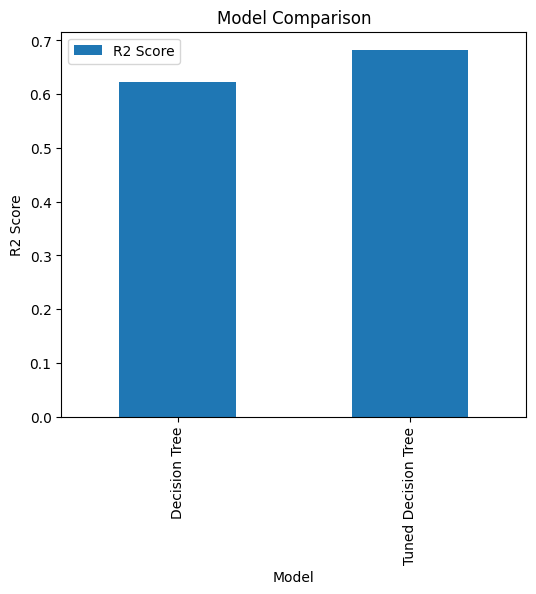

In [11]:
comparison.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    figsize=(6,5)
)

plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()